# Co-adoption of Low-Carbon Household Energy Technologies

Reproduces **Figures 2, 3 and 5** from:
> van der Kam et al. (2024). *An empirical agent-based model of consumer co-adoption of low-carbon technologies to inform energy policy.* Cell Reports Sustainability 1, 100268.

All figures are generated from live model output — nothing is hardcoded.

## 0  Imports and data

In [16]:
import itertools, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

plt.rcParams.update({
    # backgrounds
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    # all text → black
    "text.color":        "black",
    "axes.labelcolor":   "black",
    "xtick.color":       "black",
    "ytick.color":       "black",
    # spines and grid
    "axes.edgecolor":    "black",
    "grid.color":        "#cccccc",
    # legend
    "legend.facecolor":  "white",
    "legend.edgecolor":  "#cccccc",
    "legend.labelcolor": "black",
})

from co_adoption_model import Config, Simulation, load_survey
from make_figures import (
    POLICY_NAMES, POLICY_LABELS_SHORT, N_POLICIES,
    policy_vector_to_config_kwargs,
)

DATA_PATH = Path("data/surveyData.csv")
survey_df, op_PV, op_EV, op_HP, car_times = load_survey(DATA_PATH)
N_HH = len(survey_df)
print(f"Survey loaded: {N_HH} households")

Survey loaded: 1469 households


## 1  Run policy scenarios

Adjust `N_SCENARIOS` and `N_HOUSEHOLDS` to trade speed for fidelity.  
The paper used 16 384 scenarios × 1 469 households; 32 × 300 takes ~30 s.

In [17]:
# ── settings ──────────────────────────────────────────────────────────────────
N_SCENARIOS  = 25    # increase to 256 / 1024 / 16384 for more coverage
N_HOUSEHOLDS = 1469     # use 1469 for full paper fidelity
SEED         = 42
# ──────────────────────────────────────────────────────────────────────────────

rng_sample = random.Random(SEED)
all_vecs   = list(itertools.product([0, 1], repeat=N_POLICIES))
baseline_vec = tuple([0] * N_POLICIES)
allon_vec    = tuple([1] * N_POLICIES)
rest         = [v for v in all_vecs if v not in (baseline_vec, allon_vec)]
vecs = [baseline_vec] + rng_sample.sample(rest, N_SCENARIOS - 2) + [allon_vec]


def run_scenario(vec, seed):
    random.seed(seed); np.random.seed(seed)
    kw  = policy_vector_to_config_kwargs(vec)
    cfg = Config(households=N_HOUSEHOLDS, stop_after_x_years=29, **kw)
    sim = Simulation(cfg, survey_df, op_PV, op_EV, op_HP, car_times)

    years, pv, ev, hp = [], [], [], []
    co_all, co_pv_ev, co_pv_hp, co_ev_hp, single_only = [], [], [], [], []

    for tick in range(cfg.stop_after_x_years + 1):
        s = sim.summary()
        years.append(s["year"])
        pv.append(s["PV"]); ev.append(s["EV"]); hp.append(s["HP"])
        co_all.append(s["co_PV_EV_HP"])
        co_pv_ev.append(s["co_PV_EV"])
        co_pv_hp.append(s["co_PV_HP"])
        co_ev_hp.append(s["co_EV_HP"])
        only = s["co_PV_only"] + s["co_EV_only"] + s["co_HP_only"]
        single_only.append(only)
        if tick < cfg.stop_after_x_years:
            sim.go()

    # final-state demographics
    income_groups, ownership_groups = [], []
    co_adopt_status, single_adopt_status = [], []
    for p in sim.persons:
        raw_inc = p.pf(26)
        income_groups.append("High" if raw_inc > 5 else ("Mid" if raw_inc > 2 else "Low"))
        ownership_groups.append("Owner" if p.owner else "Tenant")
        n_tech = int(p.house.PV_solar_panel) + int(p.has_EV) + int(p.house.heat_pump)
        co_adopt_status.append(n_tech >= 2)
        single_adopt_status.append(n_tech == 1)

    return dict(
        vec=vec, years=years,
        PV=pv, EV=ev, HP=hp,
        co_all=co_all, co_pv_ev=co_pv_ev, co_pv_hp=co_pv_hp, co_ev_hp=co_ev_hp,
        single_only=single_only,
        income_groups=income_groups, ownership_groups=ownership_groups,
        co_adopt_status=co_adopt_status, single_adopt_status=single_adopt_status,
    )


t0 = time.time()
results = [run_scenario(v, SEED + i) for i, v in enumerate(vecs)]
print(f"Ran {len(results)} scenarios in {time.time()-t0:.0f}s")

baseline_idx = next(i for i, r in enumerate(results) if all(v == 0 for v in r["vec"]))
print(f"Baseline index: {baseline_idx}")

Ran 25 scenarios in 16s
Baseline index: 0


---
## Figure 2 — Diffusion curves across all policy scenarios

Light lines = all scenarios; black line = baseline (no policies); dashed = maximum across scenarios.

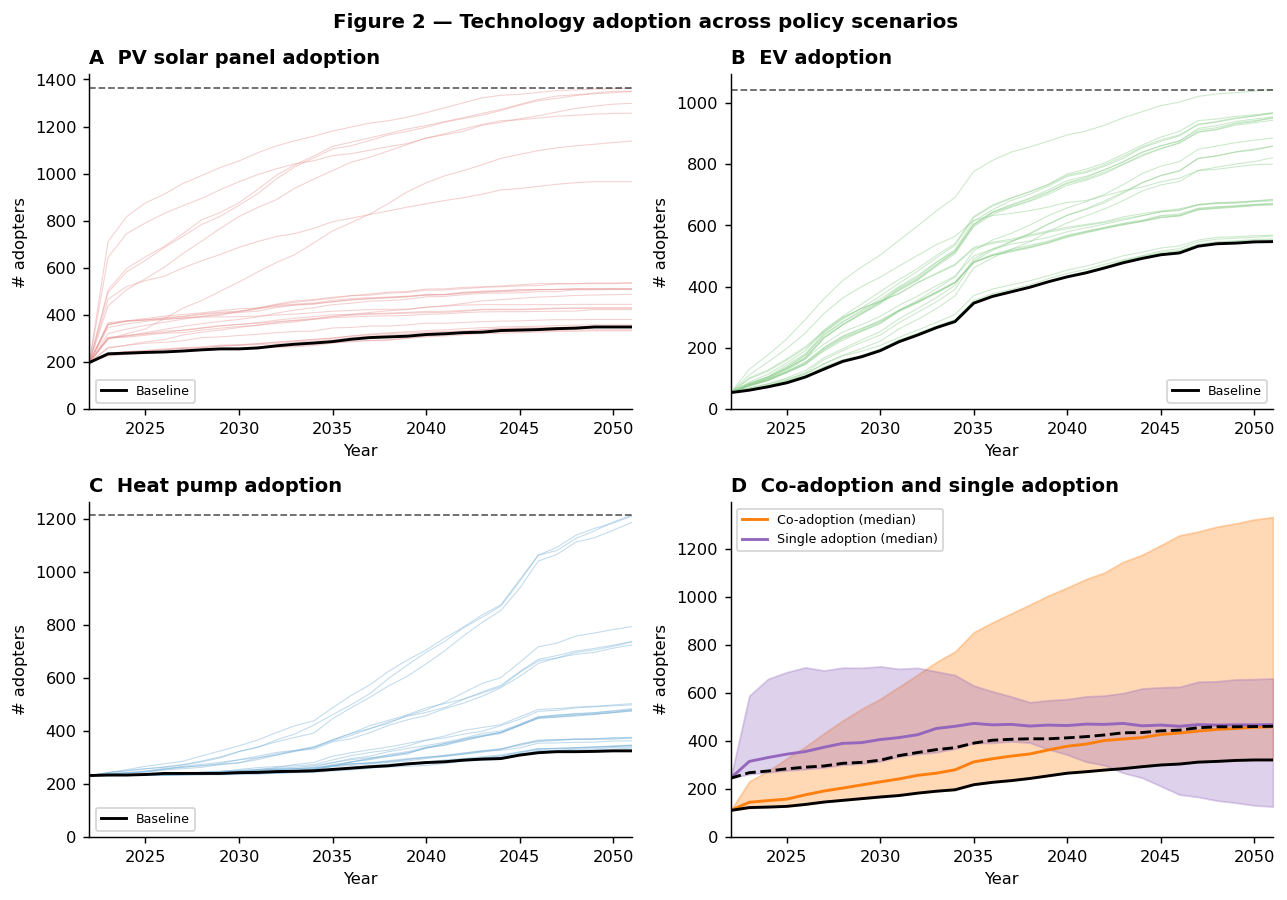

In [18]:
plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "figure.dpi": 130,
})

years = results[0]["years"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

panel_cfg = [
    ("A  PV solar panel adoption",   "PV", "#d62728", "#e89a9a"),
    ("B  EV adoption",               "EV", "#2ca02c", "#8ecf8e"),
    ("C  Heat pump adoption",        "HP", "#1f77b4", "#7ab2d8"),
]

for ax, (title, key, dark, light) in zip(axes[:3], panel_cfg):
    for r in results:
        ax.plot(years, r[key], color=light, alpha=0.45, lw=0.6)
    ax.plot(years, results[baseline_idx][key], color="black", lw=1.6, zorder=5, label="Baseline")
    pot = max(r[key][-1] for r in results)
    ax.axhline(pot, color="black", lw=1, ls="--", alpha=0.6)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("# adopters")
    ax.set_xlim(years[0], years[-1]); ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

# panel D: co-adoption vs single-only
ax = axes[3]
co_arr  = np.array([[r["co_all"][t]+r["co_pv_ev"][t]+r["co_pv_hp"][t]+r["co_ev_hp"][t]
                     for t in range(len(years))] for r in results])
sng_arr = np.array([[r["single_only"][t] for t in range(len(years))] for r in results])

ax.fill_between(years, co_arr.min(0),  co_arr.max(0),  color="#ff7f0e", alpha=0.3)
ax.fill_between(years, sng_arr.min(0), sng_arr.max(0), color="#9467bd", alpha=0.3)
ax.plot(years, np.median(co_arr,  0), color="#ff7f0e", lw=1.6, label="Co-adoption (median)")
ax.plot(years, np.median(sng_arr, 0), color="#9467bd", lw=1.6, label="Single adoption (median)")
bl = results[baseline_idx]
co_bl = [bl["co_all"][t]+bl["co_pv_ev"][t]+bl["co_pv_hp"][t]+bl["co_ev_hp"][t] for t in range(len(years))]
ax.plot(years, co_bl,             color="black", lw=1.6)
ax.plot(years, bl["single_only"], color="black", lw=1.6, ls="--")
ax.set_title("D  Co-adoption and single adoption", loc="left", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("# adopters")
ax.set_xlim(years[0], years[-1]); ax.set_ylim(bottom=0)
ax.legend(fontsize=7)

fig.suptitle("Figure 2 — Technology adoption across policy scenarios", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Figure 3 — Policy impact slope chart (2030 vs 2050)

OLS regression of each policy dimension on adoption count at 2030 and 2050.

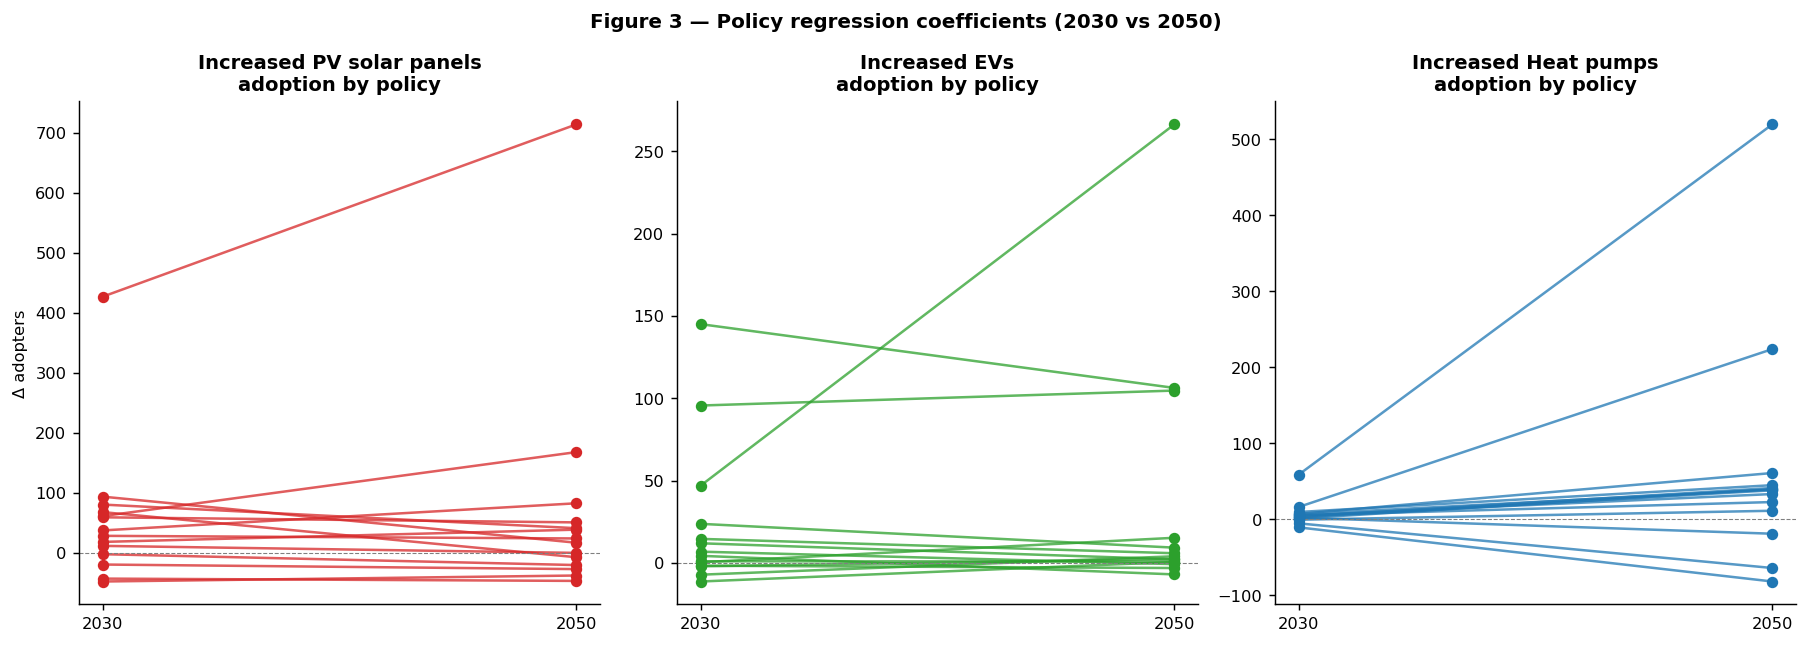

In [19]:
from sklearn.linear_model import LinearRegression

t2030 = years.index(2030)
t2050 = years.index(2050)

techs = [
    ("PV solar panels", "PV", "#d62728"),
    ("EVs",             "EV", "#2ca02c"),
    ("Heat pumps",      "HP", "#1f77b4"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

X = np.array([list(r["vec"]) for r in results], dtype=float)

for ax, (tech_name, key, col) in zip(axes, techs):
    y30 = np.array([r[key][t2030] for r in results], dtype=float)
    y50 = np.array([r[key][t2050] for r in results], dtype=float)

    coef30 = LinearRegression(fit_intercept=True).fit(X, y30).coef_
    coef50 = LinearRegression(fit_intercept=True).fit(X, y50).coef_

    order  = np.argsort(coef50)[::-1]
    ys_30  = coef30[order]
    ys_50  = coef50[order]
    labels = [POLICY_LABELS_SHORT[i] for i in order]

    for v30, v50 in zip(ys_30, ys_50):
        ax.plot([0, 1], [v30, v50], color=col, alpha=0.75, lw=1.4)
        ax.scatter([0, 1], [v30, v50], color=col, s=28, zorder=5)

    for v50, lab in zip(ys_50, labels):
        ax.annotate(lab, (1.06, v50), fontsize=6.2, va="center")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["2030", "2050"])
    ax.set_ylabel("Δ adopters" if ax is axes[0] else "")
    ax.set_title(f"Increased {tech_name}\nadoption by policy", fontweight="bold")
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure 3 — Policy regression coefficients (2030 vs 2050)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Figure 5 — Adoption by income group and home ownership

Averaged across all simulations.

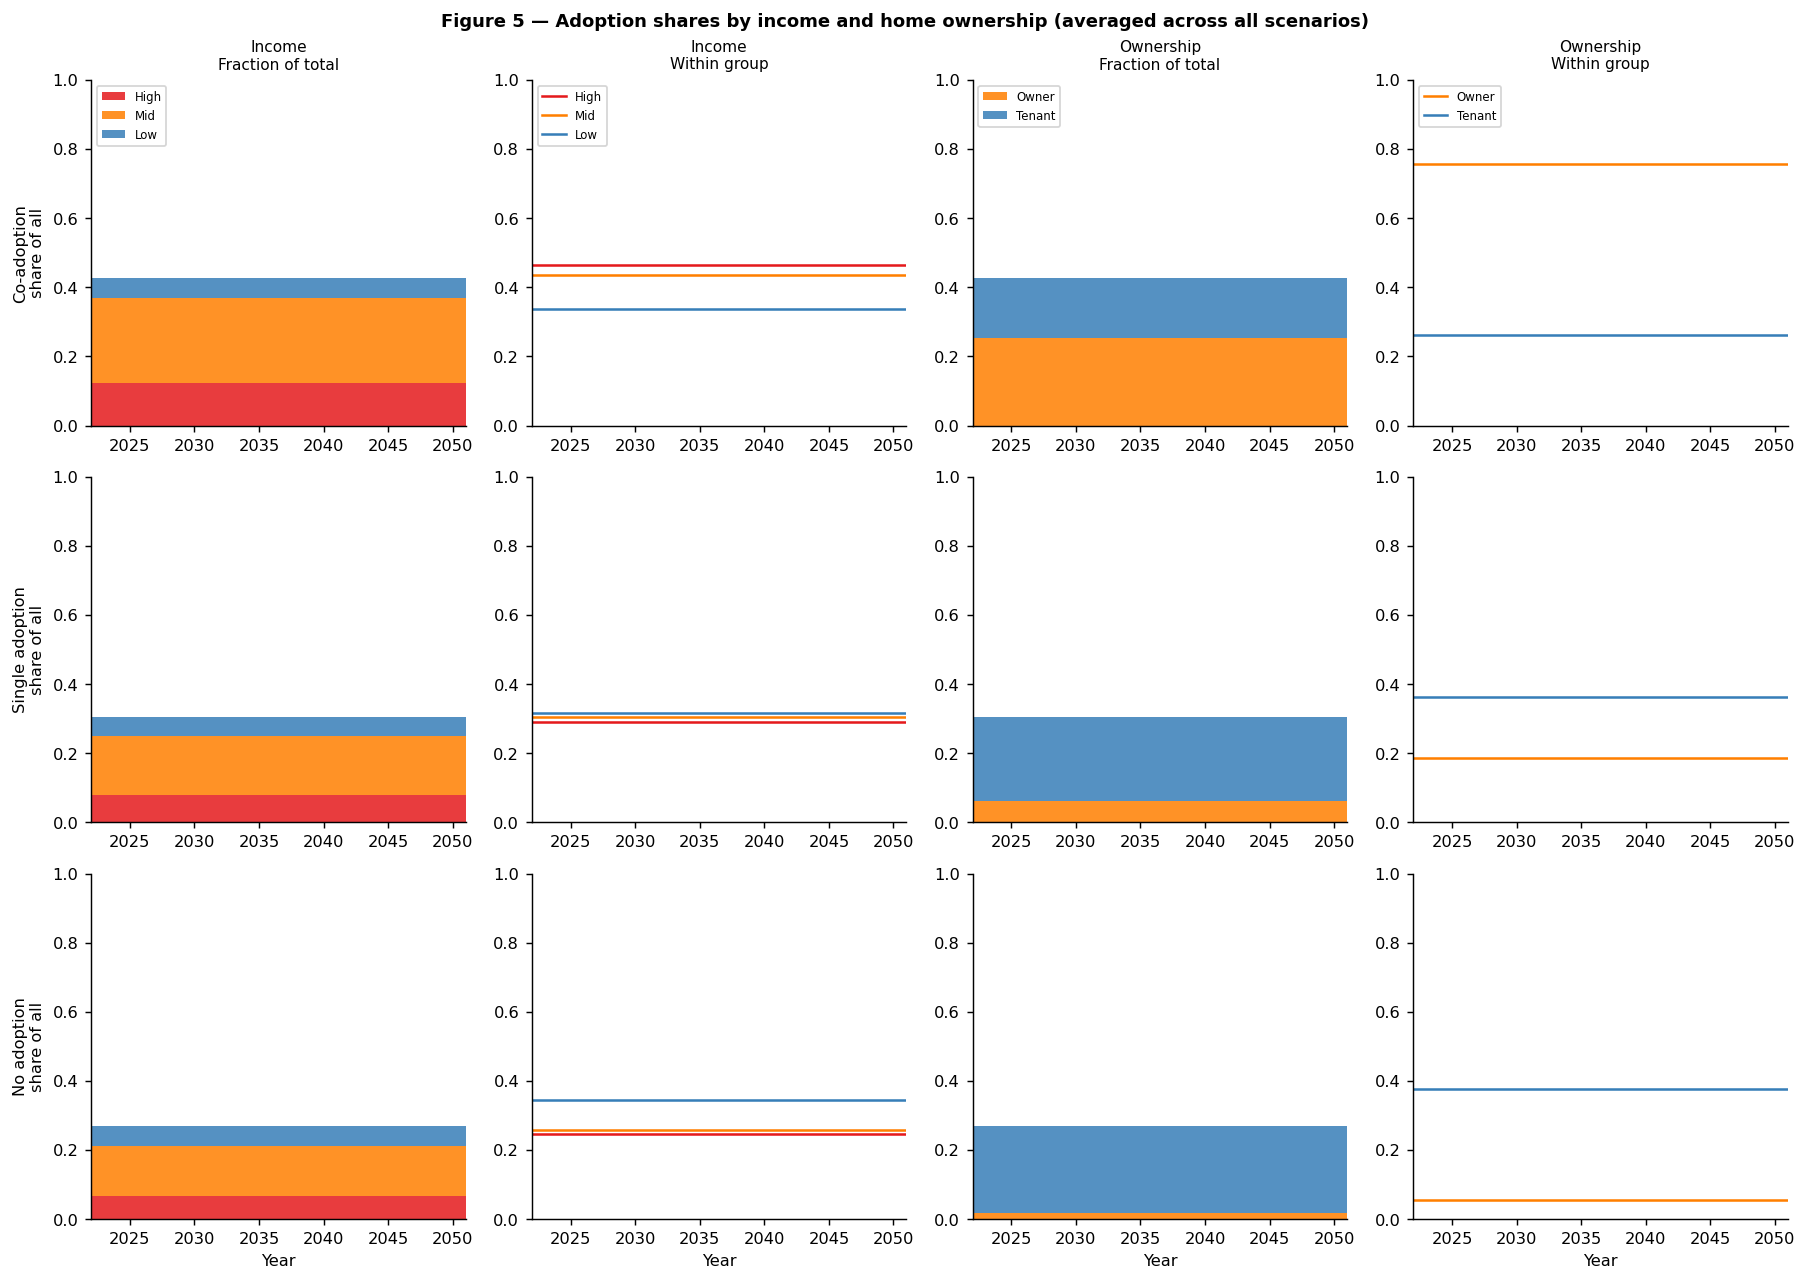

In [20]:
n_agents  = len(results[0]["income_groups"])
n_results = len(results)

income_cats = ["High", "Mid", "Low"]
own_cats    = ["Owner", "Tenant"]
inc_colors  = ["#e41a1c", "#ff7f00", "#377eb8"]
own_colors  = ["#ff7f00", "#377eb8"]
status_keys = [("co",     "Co-adoption"),
               ("single", "Single adoption"),
               ("no",     "No adoption")]


def _within_shares(results, group_key, cats, status_key):
    """Within-group share averaged over all simulations. Shape: (years, cats)."""
    acc = np.zeros((len(years), len(cats)))
    for r in results:
        groups = r[group_key]
        for ti in range(len(years)):
            for ci, cat in enumerate(cats):
                idx = [i for i, g in enumerate(groups) if g == cat]
                if not idx:
                    continue
                if status_key == "co":
                    cnt = sum(r["co_adopt_status"][i] for i in idx)
                elif status_key == "single":
                    cnt = sum(r["single_adopt_status"][i] for i in idx)
                else:
                    cnt = sum(not r["co_adopt_status"][i] and not r["single_adopt_status"][i]
                              for i in idx)
                acc[ti, ci] += cnt / len(idx)
    return acc / n_results


def _total_shares(results, group_key, cats, status_key):
    """Share of *all* agents in each group, averaged over simulations."""
    acc = np.zeros((len(years), len(cats)))
    for r in results:
        groups = r[group_key]
        for ti in range(len(years)):
            for ci, cat in enumerate(cats):
                idx = [i for i, g in enumerate(groups) if g == cat]
                if status_key == "co":
                    cnt = sum(r["co_adopt_status"][i] for i in idx)
                elif status_key == "single":
                    cnt = sum(r["single_adopt_status"][i] for i in idx)
                else:
                    cnt = sum(not r["co_adopt_status"][i] and not r["single_adopt_status"][i]
                              for i in idx)
                acc[ti, ci] += cnt / n_agents
    return acc / n_results


fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ri, (sk, row_label) in enumerate(status_keys):
    # col 0 — income, fraction of total (stacked area)
    ax = axes[ri, 0]
    s  = _total_shares(results, "income_groups", income_cats, sk)
    ax.stackplot(years, s.T, labels=income_cats, colors=inc_colors, alpha=0.85)
    ax.set_ylim(0, 1); ax.set_ylabel(f"{row_label}\nshare of all")
    if ri == 0:
        ax.set_title("Income\nFraction of total", fontsize=8.5)
        ax.legend(loc="upper left", fontsize=6.5)

    # col 1 — income, within-group share
    ax = axes[ri, 1]
    s  = _within_shares(results, "income_groups", income_cats, sk)
    for ci, (cat, col) in enumerate(zip(income_cats, inc_colors)):
        ax.plot(years, s[:, ci], color=col, lw=1.4, label=cat)
    ax.set_ylim(0, 1)
    if ri == 0:
        ax.set_title("Income\nWithin group", fontsize=8.5)
        ax.legend(loc="upper left", fontsize=6.5)

    # col 2 — ownership, fraction of total
    ax = axes[ri, 2]
    s  = _total_shares(results, "ownership_groups", own_cats, sk)
    ax.stackplot(years, s.T, labels=own_cats, colors=own_colors, alpha=0.85)
    ax.set_ylim(0, 1)
    if ri == 0:
        ax.set_title("Ownership\nFraction of total", fontsize=8.5)
        ax.legend(loc="upper left", fontsize=6.5)

    # col 3 — ownership, within-group share
    ax = axes[ri, 3]
    s  = _within_shares(results, "ownership_groups", own_cats, sk)
    for ci, (cat, col) in enumerate(zip(own_cats, own_colors)):
        ax.plot(years, s[:, ci], color=col, lw=1.4, label=cat)
    ax.set_ylim(0, 1)
    if ri == 0:
        ax.set_title("Ownership\nWithin group", fontsize=8.5)
        ax.legend(loc="upper left", fontsize=6.5)

for ax in axes.flatten():
    ax.set_xlim(years[0], years[-1])
    ax.set_xlabel("Year" if ax in axes[2] else "")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure 5 — Adoption shares by income and home ownership (averaged across all scenarios)",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Bonus — Summary statistics at 2030 and 2050

In [21]:
bl = results[baseline_idx]
best = max(results, key=lambda r: r["PV"][-1] + r["EV"][-1] + r["HP"][-1])

rows = []
for label, r in [("Baseline", bl), ("Best scenario", best)]:
    for yr in (2030, 2050):
        ti = years.index(yr)
        rows.append({
            "Scenario": label, "Year": yr,
            "PV": r["PV"][ti], "PV%": f"{r['PV'][ti]/N_HH*100:.1f}%",
            "EV": r["EV"][ti], "EV%": f"{r['EV'][ti]/N_HH*100:.1f}%",
            "HP": r["HP"][ti], "HP%": f"{r['HP'][ti]/N_HH*100:.1f}%",
        })

df_summary = pd.DataFrame(rows).set_index(["Scenario", "Year"])
print("Note: % is relative to survey size (1469 HH), not the sampled subset.")
df_summary

Note: % is relative to survey size (1469 HH), not the sampled subset.


PV    PV%    EV    EV%    HP    HP%
Scenario      Year                                       
Baseline      2030   256  17.4%   191  13.0%   243  16.5%
              2050   349  23.8%   546  37.2%   325  22.1%
Best scenario 2030  1054  71.7%   503  34.2%   344  23.4%
              2050  1361  92.6%  1038  70.7%  1187  80.8%

In [22]:
best_policies = [POLICY_NAMES[i] for i, v in enumerate(best["vec"]) if v]
print("Best scenario policies:")
for p in best_policies:
    print(f"  ✓ {p}")

Best scenario policies:
  ✓ Subsidy PV (30%)
  ✓ Subsidy EV (30%)
  ✓ Subsidy HP (30%)
  ✓ Bundle Bonus (30%)
  ✓ High savings EV
  ✓ High savings HP (+600)
  ✓ High savings PV (net bill +73.5)
  ✓ GHG standards PV (−2%/yr)
  ✓ GHG standards EV (−1%/yr)
  ✓ GHG standards HP (−2%/yr)
  ✓ Neighbourhood battery (+20% self-suff)
  ✓ Tenants can install
  ✓ Historic houses can install
  ✓ Stimulate social interaction
